In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
booking = pd.read_csv("..\\Data\\Airbnb_NY_City_04112024\\calendar.csv")
booking.head()

<positron-console-cell-5>:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2595,2024-11-04,t,$225.00,NaN,30,1125
1,2595,2024-11-05,t,$225.00,NaN,30,1125
2,2595,2024-11-06,t,$225.00,NaN,30,1125
3,2595,2024-11-07,t,$225.00,NaN,30,1125
4,2595,2024-11-08,t,$225.00,NaN,30,1125


In [14]:

booking['unavailable'] = booking['available'] == 'f'

# aggregate the booking information by listing id
grouped = booking.groupby('listing_id').agg(
    total_days=('date', 'count'),
    unavailable_days=('unavailable', 'sum')
)

# create available days column and calculate the booked ratio (unavailable days/ total days listed)
grouped['available_days'] = grouped['total_days'] - grouped['unavailable_days']
grouped['booking_ratio'] = grouped['unavailable_days'] / grouped['total_days']

grouped = grouped.reset_index()

In [20]:
grouped.head()
grouped.to_csv("..\\Data\\Airbnb_NY_City_04112024\\listing_booking_info.csv")

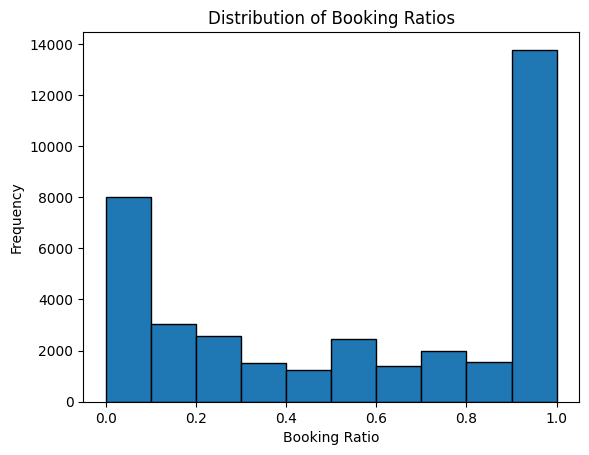

In [16]:
# visualize the booking ratio distribution

plt.hist(grouped['booking_ratio'], bins=10, edgecolor='black')

plt.xlabel('Booking Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Booking Ratios')

plt.show()